# Benchmark of feature generation

In [2]:
import pandas as pd

df = pd.read_csv("benchmark_results copy.csv")
esp = pd.read_csv("benchmark_results_esp.csv")
prosmith = pd.read_csv("benchmark_results_prosmith.csv")

In [3]:
prosmith

,pipeline,unique_enzymes,unique_substrates,num_pairs,time,memory
0,prosmith,13,18,153,0:00:49.047929,0B
1,prosmith,191,89,357,0:00:53.429013,0B
2,prosmith,3139,498,4170,0:12:46.496832,0B
3,prosmith,7000,1522,44148,0:30:31.406577,0B
4,prosmith,10387,1728,73230,0:45:04.278333,0B


In [4]:
import pandas as pd

ours_inference_esm1b = pd.read_csv("inference/benchmark_results_np_inference_esm1b.csv")
ours_inference_esm1b["pipeline"] = "XGBoost-NPClassifierFP-ESM1b inference"
ours_inference_esm2 = pd.read_csv("inference/benchmark_results_np_inference_esm2.csv")
ours_inference_esm2["pipeline"] = "XGBoost-NPClassifierFP-ESM2 inference"
ours_inference = pd.read_csv("inference/benchmark_results_np_inference_protbert.csv")
ours_inference["pipeline"] = "XGBoost-NPClassifierFP-ProtBERT inference"
esp_inference = pd.read_csv("inference/benchmark_results_inference_esp.csv")
esp_inference["pipeline"] = "ESP (state of the art) inference"

prosmith_inference = pd.read_csv("inference/benchmark_results_inference_prosmith.csv")
prosmith_inference["pipeline"] = "ProSmith (state of the art) inference"

In [5]:
esp

,pipeline,unique_enzymes,unique_substrates,num_pairs,time,memory
0,generate_features,13,18,153,0:00:34.897174,57M
1,generate_features,191,89,357,0:04:16.611926,204M
2,generate_features,3139,498,4170,1:09:53.040979,207M
3,generate_features,7000,1522,44148,2:43:34.250909,213M
4,generate_features,10387,1728,73230,3:59:03.254080,219M


In [6]:
df = pd.concat([esp_inference, prosmith_inference, ours_inference, ours_inference_esm2, ours_inference_esm1b], ignore_index=True)

In [7]:
# replace the name of pipelines with more readable names
df["pipeline"] = df["pipeline"].replace(
    {
        "process_probert": "XGBoost-NPClassifierFP-ProtBERT feature generation",
        "process_esm1b": "XGBoost-NPClassifierFP-ESM1b feature generation",
        "process_to_esm2": "XGBoost-NPClassifierFP-ESM2 feature generation",
        "generate_features": "ESP (state of the art) feature generation",
        "prosmith": "ProSmith (state of the art) feature generation",
    }
)

In [8]:
df

,unique_enzymes,unique_substrates,num_pairs,time,memory,pipeline
0,13,18,153,0:01:16.875537,57M,ESP (state of the art) inference
1,191,89,357,0:04:35.480063,204M,ESP (state of the art) inference
2,3139,498,4170,1:18:33.828044,207M,ESP (state of the art) inference
3,7000,1522,44148,2:46:03.640692,213M,ESP (state of the art) inference
4,10387,1728,73230,3:55:28.917024,218M,ESP (state of the art) inference
5,13,18,153,0:00:40.976118,128M,ProSmith (state of the art) inference
6,191,89,357,0:01:35.371059,2G,ProSmith (state of the art) inference
7,3139,498,4170,0:17:33.069058,22G,ProSmith (state of the art) inference
8,7000,1522,44148,1:37:37.749625,22G,ProSmith (state of the art) inference
9,10387,1728,73230,3:25:46.705668,22G,ProSmith (state of the art) inference


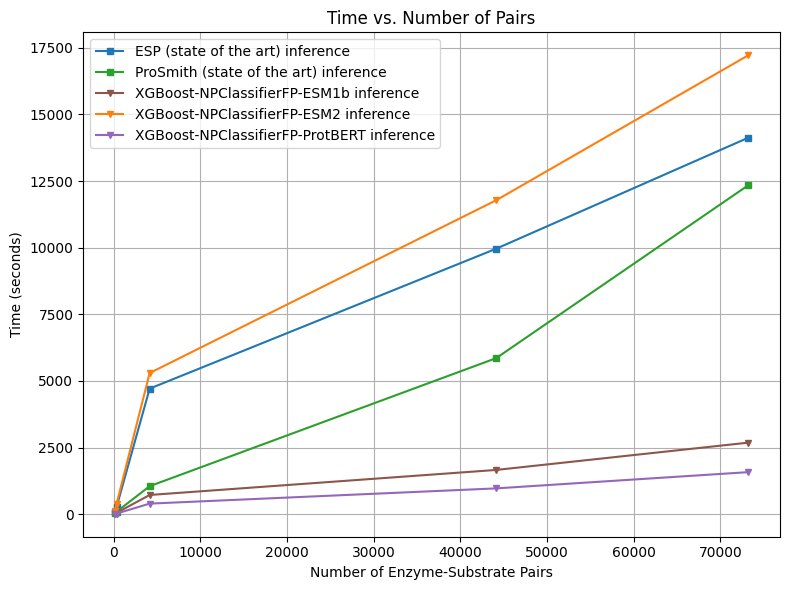

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO

def time_to_seconds(time_str):
    parts = time_str.split(':')
    if len(parts) == 3:
        h, m, s = map(float, parts)
        return h * 3600 + m * 60 + s
    else:
        m, s = map(float, parts)
        return m * 60 + s

# Assuming df is already loaded and 'time_seconds' is calculated
df['time_seconds'] = df['time'].apply(time_to_seconds)

# Define colorblind-friendly colors and line styles for each pipeline
pipeline_colors = {
    'ESP (state of the art) inference': {'color': '#1f77b4', 'linestyle': '-', 'marker': 's'}, 
    'ProSmith (state of the art) inference': {'color': '#2ca02c', 'linestyle': '-', 'marker': 's'},
    'XGBoost-NPClassifierFP-ESM2 inference': {'color': '#ff7f0e', 'linestyle': '-', 'marker': 'v'}, # Orange, dotted line with triangle marker
    'XGBoost-NPClassifierFP-ESM1b inference': {'color': '#8c564b', 'linestyle': '-', 'marker': 'v'}, # Orange, dotted line with triangle marker
    'XGBoost-NPClassifierFP-ProtBERT inference': {'color': '#9467bd', 'linestyle': '-', 'marker': 'v'}, # Orange, dotted line with triangle marker
    'BLASTp + Tanimoto': {'color': '#bcbd22', 'linestyle': '-.', 'marker': 'x'}  # Gold, dash-dot line
}

# Plot
plt.figure(figsize=(8, 6))
for pipeline, group in df.groupby('pipeline'):
    if pipeline in pipeline_colors:
        style = pipeline_colors[pipeline]
        plt.plot(
            group['num_pairs'],
            group['time_seconds'],
            label=pipeline,
            color=style['color'],
            linestyle=style['linestyle'],
            marker=style['marker'],
            markersize=5
        )

plt.title('Time vs. Number of Pairs')
plt.xlabel('Number of Enzyme-Substrate Pairs')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('time_vs_pairs.png', format='PNG', dpi=200, bbox_inches='tight', transparent=True)
plt.show()


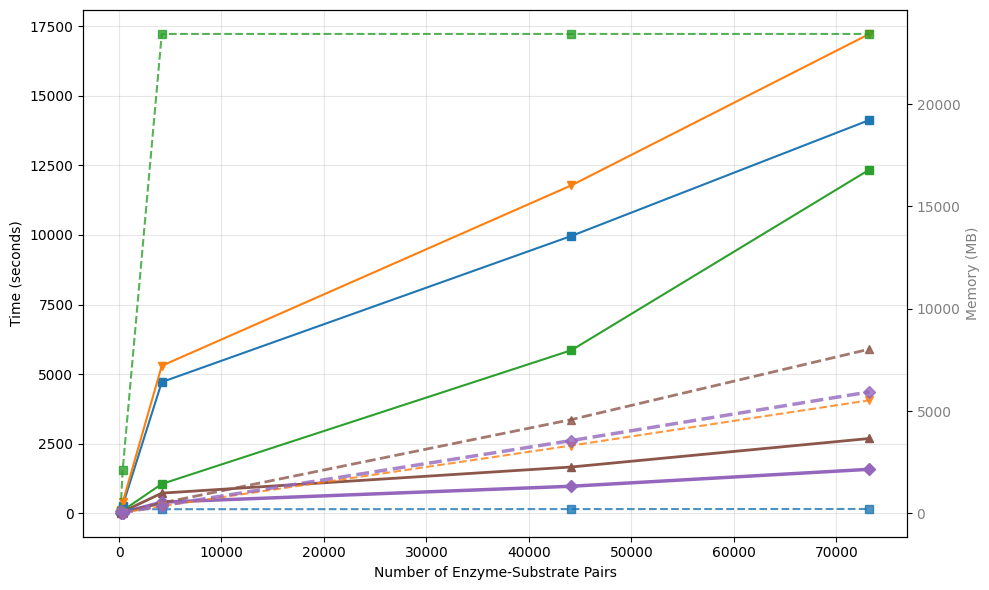

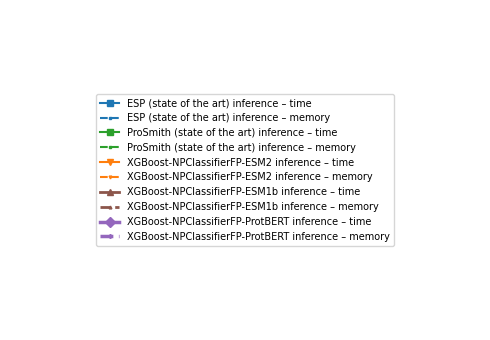

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import re
from matplotlib.lines import Line2D
import numpy as np

def time_to_seconds(time_str):
    parts = time_str.split(':')
    if len(parts) == 3:
        h, m, s = map(float, parts)
        return h * 3600 + m * 60 + s
    else:
        m, s = map(float, parts)
        return m * 60 + s

def memory_to_mb(mem_str):
    match = re.match(r'([\d.]+)([MG])', str(mem_str).strip())
    if match:
        value, unit = float(match.group(1)), match.group(2)
        return value if unit == 'M' else value * 1024
    return float(mem_str)

df['time_seconds'] = df['time'].apply(time_to_seconds)
df['memory_mb'] = df['memory'].apply(memory_to_mb)

pipeline_colors = {
    'ESP (state of the art) inference':            {'color': '#1f77b4', 'marker': 's', 'lw': 1.5},
    'ProSmith (state of the art) inference':       {'color': '#2ca02c', 'marker': 's', 'lw': 1.5},
    'XGBoost-NPClassifierFP-ESM2 inference':       {'color': '#ff7f0e', 'marker': 'v', 'lw': 1.5},
    'XGBoost-NPClassifierFP-ESM1b inference':      {'color': '#8c564b', 'marker': '^', 'lw': 2.0},
    'XGBoost-NPClassifierFP-ProtBERT inference':   {'color': '#9467bd', 'marker': 'D', 'lw': 2.5},
    'BLASTp + Tanimoto':                           {'color': '#bcbd22', 'marker': 'x', 'lw': 1.5},
}

# Small jitter multipliers per pipeline to separate overlapping memory lines
jitter = {p: 1 + i * 0.04 for i, p in enumerate(pipeline_colors)}

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

for pipeline, group in df.groupby('pipeline'):
    if pipeline in pipeline_colors:
        style = pipeline_colors[pipeline]

        # Runtime — solid line, left axis
        ax1.plot(
            group['num_pairs'], group['time_seconds'],
            color=style['color'],
            linestyle='-',
            marker=style['marker'],
            linewidth=style['lw'],
            markersize=6
        )
        # Memory — dashed line, right axis, with jitter to separate overlaps
        ax2.plot(
            group['num_pairs'], group['memory_mb'] * jitter[pipeline],
            color=style['color'],
            linestyle='--',
            marker=style['marker'],
            linewidth=style['lw'],
            markersize=6,
            alpha=0.8
        )

ax1.set_xlabel('Number of Enzyme-Substrate Pairs')
ax1.set_ylabel('Time (seconds)', color='black')
ax2.set_ylabel('Memory (MB)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_vs_pairs.png', format='PNG', dpi=200, bbox_inches='tight', transparent=True)
plt.show()

# Save legend as a separate file
legend_entries = []
for pipeline, style in pipeline_colors.items():
    if pipeline in df['pipeline'].values:
        legend_entries.append(
            Line2D([0], [0], color=style['color'], linestyle='-',
                   marker=style['marker'], markersize=5, linewidth=style['lw'],
                   label=f'{pipeline} – time')
        )
        legend_entries.append(
            Line2D([0], [0], color=style['color'], linestyle='--',
                   marker=style['marker'], markersize=2, linewidth=style['lw'],
                   label=f'{pipeline} – memory')
        )

fig_legend, ax_legend = plt.subplots(figsize=(5, len(legend_entries) * 0.3 + 0.5))
ax_legend.axis('off')
ax_legend.legend(
    handles=legend_entries,
    fontsize=7,
    loc='center',
    borderaxespad=0
)
plt.tight_layout()
plt.savefig('time_vs_pairs_legend.png', format='PNG', dpi=200, bbox_inches='tight', transparent=True)
plt.show()

In [35]:
import pandas as pd 

print(pd.read_csv("benchmark_efficiency_optimize_hyperparameters.csv").to_latex(index=False))

\begin{tabular}{lll}
\toprule
               pipeline &                  time & memory \\
\midrule
     experiment\_np\_esm2 &        4:02:15.181873 &     0B \\
experiment\_prot\_bert\_np &        4:48:00.006736 &     0B \\
       experiment\_esm1b &        9:04:09.702522 &     0B \\
                    ESP & 1 day, 0:28:51.373444 &   622M \\
               ProSmith &                1 week &     0B \\
\bottomrule
\end{tabular}



/tmp/ipykernel_1693382/2834064685.py:3: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(pd.read_csv("benchmark_efficiency_optimize_hyperparameters.csv").to_latex(index=False))
